In [52]:
# general libraries
import pandas as pd
import numpy as np
from collections import Counter
import itertools
import random
import math
from tqdm.auto import tqdm
from tqdm import tqdm
import os
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import string
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import textstat

# sklearn
from sklearn.preprocessing import LabelEncoder, FunctionTransformer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# nltk
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# bert related imports
from transformers import RobertaTokenizer, RobertaModel
from transformers import BertTokenizer, BertModel
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

In [53]:
# some static seeds
random.seed(28)
np.random.seed(28)
torch.manual_seed(28)
torch.cuda.manual_seed(28)
os.environ['PYTHONHASHSEED'] = '28'

## Task 1: Extract insights from data

In [54]:
tweets = pd.read_csv('TweetSentiment.csv').dropna()

sentiments = ["positive", "neutral", "negative"]
# default sentiments order
tweets['sentiment'] = pd.Categorical(tweets['sentiment'], categories=sentiments, ordered=True)
# colours for plotting
sentiment_colors = ["#159b4d", "#0a92f3", "#e53522"]
sentiment_palette = dict(zip(sentiments, sentiment_colors)) # (for sns)

tweets.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on the releases we already bought",negative


In [55]:
tweets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27480 entries, 0 to 27480
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   text       27480 non-null  object  
 1   sentiment  27480 non-null  category
dtypes: category(1), object(1)
memory usage: 456.3+ KB


In [56]:
tweets['sentiment'].value_counts()

sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

### Tweet lengths

In [57]:
tweets['tweet_length'] = tweets['text'].str.len()
print(f"Tweets range from {min(tweets['tweet_length'])} to {max(tweets['tweet_length'])} characters.")

Tweets range from 3 to 141 characters.


Text(0.5, 0, 'Character lengths of tweets')

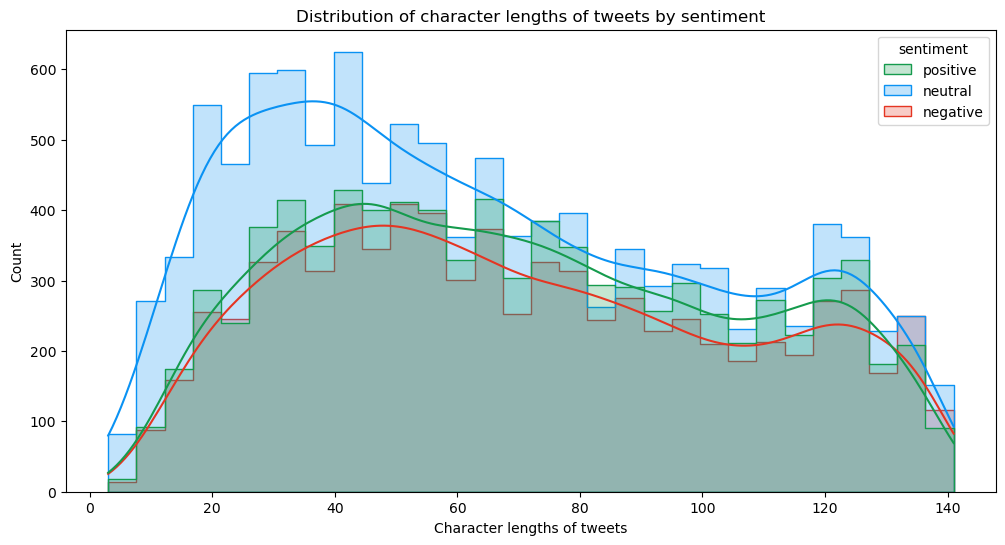

In [58]:
plt.figure(figsize=(12,6))
sns.histplot(data=tweets, x='tweet_length', hue='sentiment', bins=30, kde=True, element='step',  palette=sentiment_palette)
plt.title('Distribution of character lengths of tweets by sentiment')
plt.xlabel('Character lengths of tweets')

### Number of unique words

Number of unique tokens in the data set: 52270.
Number of unique tokens with neutral sentiment: 27043.
Number of unique tokens with negative sentiment: 20397.
Number of unique tokens with positive sentiment: 21802.


Text(0.5, 1.0, 'Number of words present per tweet by sentiment')

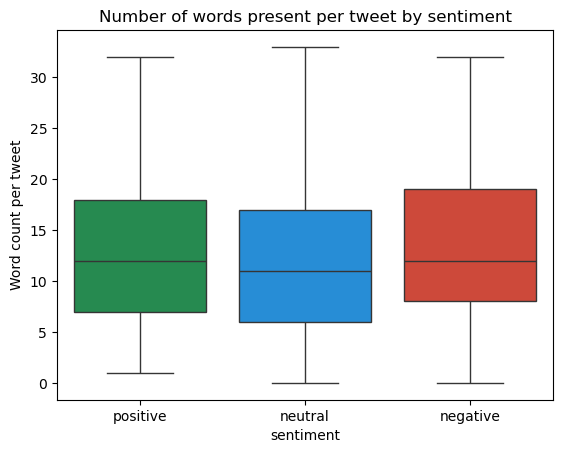

In [59]:
unique_tokens = set(" ".join(tweets['text'].dropna()).split())
print(f"Number of unique tokens in the data set: {len(unique_tokens)}.")

for sentiment in tweets['sentiment'].unique():
    unique_tokens = set(" ".join(tweets[tweets['sentiment'] == sentiment]['text'].dropna()).split())
    print(f"Number of unique tokens with {sentiment} sentiment: {len(unique_tokens)}.")

tweets['lexicon_count'] = tweets['text'].astype('str').apply(textstat.lexicon_count)
sns.boxplot(data=tweets, x='sentiment', y='lexicon_count', hue= 'sentiment', palette=sentiment_palette)
plt.ylabel('Word count per tweet')
plt.title('Number of words present per tweet by sentiment')

### Word cloud for each class

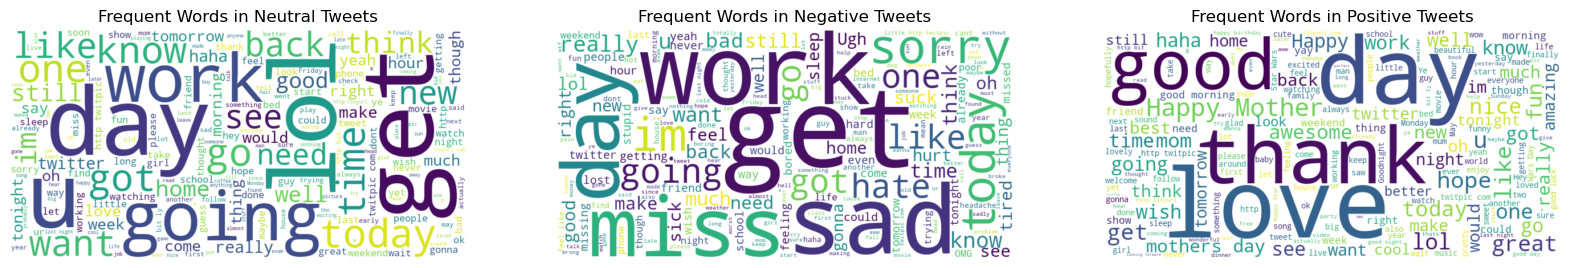

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
for ax, sentiment in zip(axes, tweets['sentiment'].unique()):
    text = " ".join(tweets[tweets['sentiment'] == sentiment]['text'].astype('str'))
    word_cloud = WordCloud(width=800, height=400, stopwords=set(stopwords.words('english')), background_color = 'white').generate(text)
    ax.imshow(word_cloud, interpolation='bilinear')
    ax.set_title(f'Frequent Words in {sentiment.capitalize()} Tweets')
    ax.axis('off')

In [61]:
# Let's see if there are any URLs, emojis, @ user mentions, hashtags or censored swear words that we need to take care off. Considered emojis as well but none (except for very few ';)' and ';-)' present.
def pattern_analysis(text_data):

    mention_pattern = r'@(\w+)'
    url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
    hashtag_pattern = r'#(\w+)'
    swearword_pattern = r'\*{4,}'
    ellipsis_pattern = r'\.{3,}'

    mentions, urls, hashtags, swearwords, ellipsis = [], [], [], [], []

    for text in text_data:
        found_mentions = re.findall(mention_pattern, text)
        mentions.extend(found_mentions)

        found_urls = re.findall(url_pattern, text)
        urls.extend(found_urls)

        found_hashtags = re.findall(hashtag_pattern, text)
        hashtags.extend(found_hashtags)

        found_swearwords = re.findall(swearword_pattern, text)
        swearwords.extend(found_swearwords)

        found_ellipsis = re.findall(ellipsis_pattern, text)
        ellipsis.extend(found_ellipsis)

    mention_counts = Counter(mentions)
    url_counts = Counter(urls)
    hashtag_counts = Counter(hashtags)

    results = {
        'total_mention_count': len(mentions),
        'total_url_count': len(urls),
        'total_hashtag_count': len(hashtags),
        'total_swearword_count': len(swearwords),
        'total_ellipsis_count': len(ellipsis),
        'mention_frequencies': mention_counts,
        'url_frequencies': url_counts,
        'hashtag_frequencies': hashtag_counts,
    }

    return results

pattern_counts = pattern_analysis(tweets['text'])

print(f"Total User Mentions: {pattern_counts['total_mention_count']}")
print(f"Total URLs: {pattern_counts['total_url_count']}")
print(f"Total Hashtags: {pattern_counts['total_hashtag_count']}")
print(f"Total Swearwords: {pattern_counts['total_swearword_count']}")
print(f"Total Ellipsis: {pattern_counts['total_ellipsis_count']}")


if pattern_counts['mention_frequencies']:
    print("Most Common Mentions:")
    for mention, count in pattern_counts['mention_frequencies'].most_common()[:5]:
        print(f"  @{mention}: {count} times")

if pattern_counts['url_frequencies']:
    print("URLs:")
    for url, count in pattern_counts['url_frequencies'].most_common()[:5]:
        print(f"  {url}: {count} times")

if pattern_counts['hashtag_frequencies']:
    print("Hashtags:")
    for hashtag, count in pattern_counts['hashtag_frequencies'].most_common()[:5]:
        print(f"  #{hashtag}: {count} times")

Total User Mentions: 74
Total URLs: 1246
Total Hashtags: 599
Total Swearwords: 1078
Total Ellipsis: 4859
Most Common Mentions:
  @_supernatural_: 4 times
  @_erica: 3 times
  @_elj: 2 times
  @_writersblock_: 2 times
  @_hayles: 2 times
URLs:
  http://blip.fm/: 73 times
  http://tweet.sg: 10 times
  http://ustre.am/2w5v): 5 times
  http://twitpic.com/67hac: 5 times
  http://gykd.net: 3 times
Hashtags:
  #fb: 31 times
  #followfriday: 18 times
  #bgt: 11 times
  #BGT: 9 times
  #starwarsday: 9 times


Let's make sure to remove @ mentions as well as URLs as these don't add much linguistic value, however the hashtags could be important so we will make sure to keep them.

## Task 2: Pre-processing

Lower casing useful, lots of punctuation so removing that also a good idea. Have to be careful with other noise removal as we don't want to for example remove hashtags. Emojis also looked for but none in there.

Numbers should be ok to remove as not overly meaningful in this dataset/ should not contribute too much to the overall sentiment of a tweet.

I will be testing the use of both Lemmatisation and Stemming. These steps can be handled internally by TfidfVectorizer or CountVectorizer. I will run it as part of the model pipeline therefore.

### Lower-casing/ removing numbers, punctuation, URLs and @ mentions

In [65]:
def normalise_tweets(text):
    text = text.lower() # lower casing everything
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # remove urls
    text = re.sub(r'\@\w+', '', text) # remove mentions
    text = re.sub(r'\.{3,}', ' ellipsistoken ', text) # replace ellipsis with a unique token
    text = re.sub(r'\*{4,}', ' swearwordtoken ', text) # replace swearwords with a unique token
    text = re.sub(r'[^a-z\s]', '', text) # remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip() # normalising whitespace
    return text

tweets = pd.read_csv('TweetSentiment.csv').dropna()
tweets['text'] = [normalise_tweets(t) for t in tweets['text']]

## Task 3: Text classification

### Stop words

In [66]:
# standard nltk stop words is a good start but contains words such as 'not' or 'no' which are quite important markers of sentiment. 
stop_words = set(stopwords.words('english'))
words_to_keep = {'no', 'not', 'nor', 'but', 'against', 'very'}
# we should keep them
stop_words.difference_update(words_to_keep)

# adding a few common words that don't really add much sentiment meaning
internet_language_noise = {'dm', 'pls', 'u', 'r'}
stop_words.update(internet_language_noise)

### Grid Search: Lemmatisation/ Stemming, Stop words and oversampling to resolve class imbalances, Naive-Bayes hyperparameters

In [67]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# we need to make sure stop_words, if used, are also stemmed or lemmatised in the same way as the rest of the corpus
stemmed_stop_words = [stemmer.stem(word) for word in stop_words]
lemmatized_stop_words = [lemmatizer.lemmatize(word) for word in stop_words]

protected_tokens = ["ellipsistoken", "swearwordtoken"] # protect our custom tokens

def stemming_tokenizer(doc):
    return [t if t in protected_tokens else stemmer.stem(t) for t in word_tokenize(doc)]

def lemmatizing_tokenizer(doc):
    return [t if t in protected_tokens else lemmatizer.lemmatize(t) for t in word_tokenize(doc)]

pipeline = Pipeline([
    ('vectorizer', CountVectorizer()), 
    ('sampler', SMOTE()), # smote uses oversampling to solve the class imbalance
    ('classifier', MultinomialNB())
])

parameters = [
    # without removing stop words - in almost all cases stop words improved model performance therefore not testing any more
    {
        # 'vectorizer': [CountVectorizer(), TfidfVectorizer()],
        # 'vectorizer__tokenizer': [None, stemming_tokenizer, lemmatizing_tokenizer],
        # 'vectorizer__stop_words': [None],
        # 'vectorizer__ngram_range': [(1, 1), (1, 2), (2, 2), (1,3), (2,3), (3,3)],
        # 'classifier__alpha': [1.0, 2.0, 3.0, 4.0],
        # 'sampler': [SMOTE(), 'passthrough'] # testing both with an without smote
    },
    
    # stemming with stemmed stop words
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],
        'vectorizer__tokenizer': [stemming_tokenizer],
        'vectorizer__stop_words': [stemmed_stop_words],
        'vectorizer__ngram_range': [(1, 1), (1, 2), (2, 2), (1,3), (2,3), (3,3)],
         'classifier__alpha': [1.0, 2.0, 3.0, 4.0], # standard value is 1 but earlier results show higher value better here
        'sampler': [SMOTE(), 'passthrough'] # testing both with an without smote
    },

    # lemmatisation with lemmatised stop words
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],
        'vectorizer__tokenizer': [lemmatizing_tokenizer],
        'vectorizer__stop_words': [lemmatized_stop_words],
        'vectorizer__ngram_range': [(1, 1), (1, 2), (2, 2), (1,3), (2,3), (3,3)],
         'classifier__alpha': [1.0, 2.0, 3.0, 4.0],
        'sampler': [SMOTE(), 'passthrough'] # testing both with an without smote
    }
]

# use stratify to ensure uneven distribution of neutral, positive, negative sentiments stays the same in train and test sets as in original data
X_train, X_test, y_train, y_test = train_test_split(tweets['text'], tweets['sentiment'], test_size=0.2, stratify=tweets['sentiment'])

grid_search = GridSearchCV(pipeline, parameters, n_jobs=-1, verbose=0, cv=5)
grid_search.fit(X_train, y_train)

python(11220) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11221) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11222) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11223) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11224) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11225) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11226) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11227) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


KeyboardInterrupt: 

In [15]:
results_df = pd.DataFrame(grid_search.cv_results_)

relevant_columns = [
    'rank_test_score',
    'param_vectorizer',
    'param_vectorizer__tokenizer',
    'param_vectorizer__stop_words',
    'param_vectorizer__ngram_range',
    'mean_test_score',
    'param_classifier__alpha',
    'param_sampler'
]

sorted_results_df = results_df.sort_values(by='rank_test_score')
display(sorted_results_df[relevant_columns].set_index('rank_test_score').head(10))

,param_vectorizer,param_vectorizer__tokenizer,param_vectorizer__stop_words,param_vectorizer__ngram_range,mean_test_score,param_classifier__alpha,param_sampler
rank_test_score,,,,,,,
1,CountVectorizer(),<function stemming_tokenizer at 0x3282160c0>,"[from, own, too, hadn't, whi, didn, becaus, sh...","(1, 1)",0.658889,3.0,passthrough
2,CountVectorizer(),<function stemming_tokenizer at 0x3282160c0>,"[from, own, too, hadn't, whi, didn, becaus, sh...","(1, 1)",0.656932,2.0,passthrough
3,CountVectorizer(),<function stemming_tokenizer at 0x3282160c0>,"[from, own, too, hadn't, whi, didn, becaus, sh...","(1, 1)",0.656796,4.0,passthrough
4,TfidfVectorizer(),<function stemming_tokenizer at 0x3282160c0>,"[from, own, too, hadn't, whi, didn, becaus, sh...","(1, 3)",0.656159,4.0,SMOTE()
5,CountVectorizer(),<function lemmatizing_tokenizer at 0x30fb8d580>,"[from, own, too, hadn't, why, didn, because, s...","(1, 1)",0.655932,3.0,passthrough
6,CountVectorizer(),<function lemmatizing_tokenizer at 0x30fb8d580>,"[from, own, too, hadn't, why, didn, because, s...","(1, 1)",0.654703,2.0,passthrough
7,CountVectorizer(),<function lemmatizing_tokenizer at 0x30fb8d580>,"[from, own, too, hadn't, why, didn, because, s...","(1, 1)",0.654021,4.0,passthrough
8,TfidfVectorizer(),<function stemming_tokenizer at 0x3282160c0>,"[from, own, too, hadn't, whi, didn, becaus, sh...","(1, 3)",0.653748,3.0,SMOTE()
9,CountVectorizer(),<function lemmatizing_tokenizer at 0x30fb8d580>,"[from, own, too, hadn't, why, didn, because, s...","(1, 2)",0.652748,2.0,passthrough


### Naive-Bayes Final Model

/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'", "'d", "'ll", "'m", 'becau', 'could', 'might', 'must', "n't", 'need', 'sha', 'v', 'wo', 'would'] not in stop_words.
  warnings.warn(



Classification Report:
              precision    recall  f1-score   support

    negative       0.66      0.65      0.66      1556
     neutral       0.62      0.63      0.62      2223
    positive       0.71      0.71      0.71      1717

    accuracy                           0.66      5496
   macro avg       0.67      0.66      0.66      5496
weighted avg       0.66      0.66      0.66      5496


--- Error Analysis Examples (First 10) ---


,Text,True Label,Predicted Label
10861,im a giver and life rewards the takers we givers make takers possible but we get no appreciation for what we dowe just get taken,negative,neutral
13642,any chance you might come back to moncton i had to miss the show tonight,negative,neutral
17429,thanks i registered,neutral,positive
27401,oh silence verona i am wanting to go jaja enjoyyitverymuch and bring me phothos of danny and dougie,positive,neutral
10112,creek no worries thank google theres nothing you cant find on there,positive,neutral
17754,read your status update just wanted b sure i was on your follow list hope u r having a wondefl wkend michaelblessings,positive,neutral
2066,jayr oh i know how budgeting is,neutral,negative
769,shower class more class taking care of my ladyfriend writing like theres no tomorrow,positive,neutral
13996,doing the andy dance the one on fonzie gomez show haha,neutral,positive
20058,follow me please so i can dm you ellipsistoken,neutral,positive


Text(0.5, 1.0, 'Confusion Matrix')

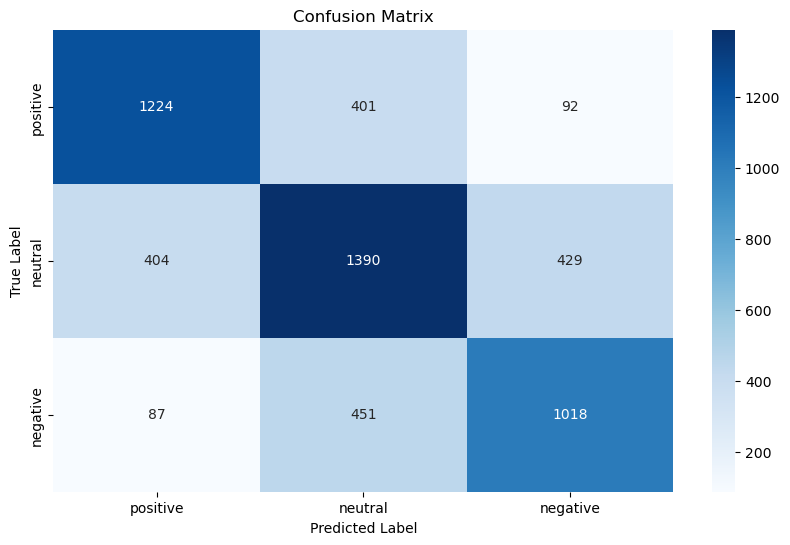

In [70]:
# use stratify to ensure uneven distribution of neutral, positive, negative sentiments stays the same in train and test sets as in original data
X_train, X_test, y_train, y_test = train_test_split(tweets['text'], tweets['sentiment'], test_size=0.2, stratify=tweets['sentiment'])

pipeline = Pipeline([
    ('bow', CountVectorizer(tokenizer=stemming_tokenizer, ngram_range= (1, 1), stop_words=stemmed_stop_words)),
    ('oversample', SMOTE(sampling_strategy='not majority')),
    ('NB classifier', MultinomialNB(alpha=3.0)) # train naive bayes classifier
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

error_mask = (y_pred != y_test)
misclassified_texts = X_test[error_mask]
true_labels_for_errors = y_test[error_mask]
predicted_labels_for_errors = y_pred[error_mask]
error_df = pd.DataFrame({
    'Text': misclassified_texts,
    'True Label': true_labels_for_errors,
    'Predicted Label': predicted_labels_for_errors
})

print("\n--- Error Analysis Examples (First 10) ---")
pd.set_option('display.max_colwidth', 280)
display(error_df.head(10))

# confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred, labels=['positive', 'neutral', 'negative'])
plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'neutral', 'negative'], yticklabels=['positive', 'neutral', 'negative'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

### Feed-forward Neural Network

### Grid Search: Lemmatisation/ Stemming, Stop words and oversampling to resolve class imbalances, Neural Network hyperparameters

In [71]:
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()), 
    ('sampler', SMOTE()), # oversampling to solve the class imbalance
    ('classifier', MLPClassifier(max_iter=150,
        early_stopping=True,
        verbose=True,
        n_iter_no_change=5,
        validation_fraction=0.2))
])

# encoding the labels into numerical labels
le = LabelEncoder()
sentiment_encoded = le.fit_transform(tweets['sentiment'])

X_train, X_test, y_train, y_test = train_test_split(
    tweets['text'], sentiment_encoded, test_size=0.2, stratify=sentiment_encoded
)

parameters = [
    # without removing stop words - in almost all cases stop words improved model performance therefore not testing any more
    # {
    #     'vectorizer': [CountVectorizer(), TfidfVectorizer()],
    #     'vectorizer__tokenizer': [None, stemming_tokenizer, lemmatizing_tokenizer],
    #     'vectorizer__stop_words': [None],
    #     'vectorizer__ngram_range': [(1, 1)],
    #     'classifier__hidden_layer_sizes': [(128,64), (100,), (50, 25)],
        # 'classifier__alpha': [0.0001, 0.001],
        # 'classifier__learning_rate_init': [0.001, 0.01],
        # 'classifier__activation': ['relu', 'tanh'],
    # },
    
    # stemming with stemmed stop words
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],
        'vectorizer__tokenizer': [stemming_tokenizer],
        'vectorizer__stop_words': [stemmed_stop_words],
        'vectorizer__ngram_range': [(1, 1)],
        'classifier__hidden_layer_sizes': [(128,64), (100,), (50, 25)],
        'classifier__alpha': [0.0001, 0.001],
        'classifier__learning_rate_init': [0.001, 0.01],
        'classifier__activation': ['relu', 'tanh'],
    },

    # lemmatisation with lemmatised stop words
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],
        'vectorizer__tokenizer': [lemmatizing_tokenizer],
        'vectorizer__stop_words': [lemmatized_stop_words],
        'vectorizer__ngram_range': [(1, 1)],
        'classifier__hidden_layer_sizes': [(128,64), (100,), (50, 25)],
        'classifier__alpha': [0.0001, 0.001],
        'classifier__learning_rate_init': [0.001, 0.01],
        'classifier__activation': ['relu', 'tanh'],
    }
]

grid_search = GridSearchCV(pipeline, parameters, n_jobs=-1, verbose=0, cv=2)
grid_search.fit(X_train, y_train)

python(11255) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11256) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11257) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11258) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11259) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11260) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11261) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11262) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/pytho

KeyboardInterrupt: 

In [ ]:
results_df = pd.DataFrame(grid_search.cv_results_)
relevant_columns = [
    'rank_test_score',
    'param_vectorizer',
    'param_vectorizer__tokenizer',
    'param_vectorizer__stop_words',
    'param_vectorizer__ngram_range',
    'mean_test_score',
    'param_classifier__hidden_layer_sizes',
    # 'param_sampler'
]

sorted_results_df = results_df.sort_values(by='rank_test_score')
display(sorted_results_df[relevant_columns].set_index('rank_test_score').head(10))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


### Neural network: Final Model

/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'ll", "'m", "'re", "'s", "'ve", 'could', 'might', 'must', "n't", 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(


Iteration 1, loss = 1.11024100
Validation score: 0.335769
Iteration 2, loss = 1.03648135
Validation score: 0.684280
Iteration 3, loss = 0.89031914
Validation score: 0.750984
Iteration 4, loss = 0.69038465
Validation score: 0.765786
Iteration 5, loss = 0.48685022
Validation score: 0.769346
Iteration 6, loss = 0.32389829
Validation score: 0.771220
Iteration 7, loss = 0.21512673
Validation score: 0.773093
Iteration 8, loss = 0.14768607
Validation score: 0.773093
Iteration 9, loss = 0.10624336
Validation score: 0.775904
Iteration 10, loss = 0.07991615
Validation score: 0.775155
Iteration 11, loss = 0.06245066
Validation score: 0.775155
Iteration 12, loss = 0.05042604
Validation score: 0.775529
Iteration 13, loss = 0.04178877
Validation score: 0.774780
Iteration 14, loss = 0.03539000
Validation score: 0.772906
Iteration 15, loss = 0.03050882
Validation score: 0.773656
Validation score did not improve more than tol=0.000100 for 5 consecutive epochs. Stopping.

Classification Report:
        

,Text,True Label,Predicted Label
108,have a safe trip joshy poo ellipsistoken youll knock them dead at your speech,positive,neutral
11250,so wanted to go to the basshunter concert tonight so so so wanted to,positive,neutral
10661,such a busy day today banbury fair fashion show tonight and move into my apartment tomorrow i have no started packing yet,negative,neutral
11604,oh when will gfail end been on html version all day,negative,positive
7576,baby help me with math,positive,negative
13159,please please please please let my match be cancelled today please,positive,neutral
10909,he is the meanest lil boy ever when i was a lil girl everyone loved me,neutral,positive
18353,damnit day is at northpark malli use to live near there someone steal mike for meeee,negative,neutral
24271,rocks just spurted fanta out of my mouth laughing at that,neutral,positive
6478,hungry but dont have an appetite,negative,neutral


Text(0.5, 1.0, 'Confusion Matrix')

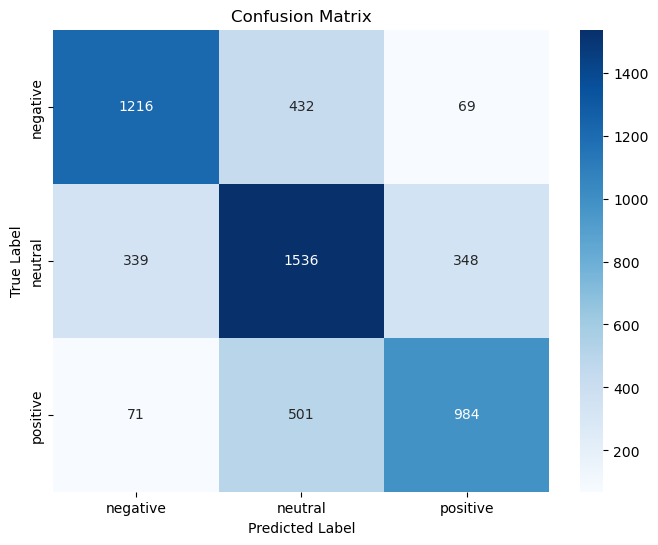

In [79]:
# encoding the labels into numerical labels
le = LabelEncoder()
sentiment_encoded = le.fit_transform(tweets['sentiment'])

X_train, X_test, y_train, y_test = train_test_split(
    tweets['text'], sentiment_encoded, test_size=0.2, stratify=sentiment_encoded
)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(tokenizer=lemmatizing_tokenizer, ngram_range= (1, 3), stop_words=lemmatized_stop_words)),
    ('oversample', SMOTE(sampling_strategy='not majority')),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(128,64),
        learning_rate_init = 0.0001, # slowing down works slighly better
        max_iter=150, # trying to speed up a bit
        early_stopping=True,
        verbose=True,
        n_iter_no_change=5,
        validation_fraction=0.2
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

y_pred = le.inverse_transform(y_pred)
y_test = le.inverse_transform(y_test)

print("\nClassification Report:")
target_names = le.classes_
print(classification_report(y_test, y_pred))

error_mask = (y_pred != y_test)
misclassified_texts = X_test[error_mask]
true_labels_for_errors = y_test[error_mask]
predicted_labels_for_errors = y_pred[error_mask]
error_df = pd.DataFrame({
    'Text': misclassified_texts,
    'True Label': true_labels_for_errors,
    'Predicted Label': predicted_labels_for_errors
})

print("\n--- Error Analysis Examples (First 10) ---")
pd.set_option('display.max_colwidth', 280)
display(error_df.head(10))
conf_matrix = confusion_matrix(y_test, y_pred, labels=['positive', 'neutral', 'negative'])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')]
plt.savefig('mlp_conf_matrix.png')

### Dropping instances of neutral class

/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'ll", "'m", "'re", "'s", "'ve", 'could', 'might', 'must', "n't", 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(


Iteration 1, loss = 0.69104925
Validation score: 0.525127
Iteration 2, loss = 0.67003938
Validation score: 0.845958
Iteration 3, loss = 0.62267683
Validation score: 0.854334
Iteration 4, loss = 0.55149736
Validation score: 0.854698
Iteration 5, loss = 0.46775980
Validation score: 0.855426
Iteration 6, loss = 0.38036726
Validation score: 0.861253
Iteration 7, loss = 0.29987541
Validation score: 0.867808
Iteration 8, loss = 0.23146039
Validation score: 0.869264
Iteration 9, loss = 0.17649612
Validation score: 0.869264
Iteration 10, loss = 0.13393834
Validation score: 0.870357
Iteration 11, loss = 0.10240149
Validation score: 0.871085
Iteration 12, loss = 0.07946538
Validation score: 0.871449
Iteration 13, loss = 0.06279207
Validation score: 0.872542
Iteration 14, loss = 0.05050490
Validation score: 0.872542
Iteration 15, loss = 0.04130186
Validation score: 0.872178
Iteration 16, loss = 0.03434721
Validation score: 0.872542
Iteration 17, loss = 0.02893233
Validation score: 0.871814
Iterat

Text(0.5, 1.0, 'Confusion Matrix')

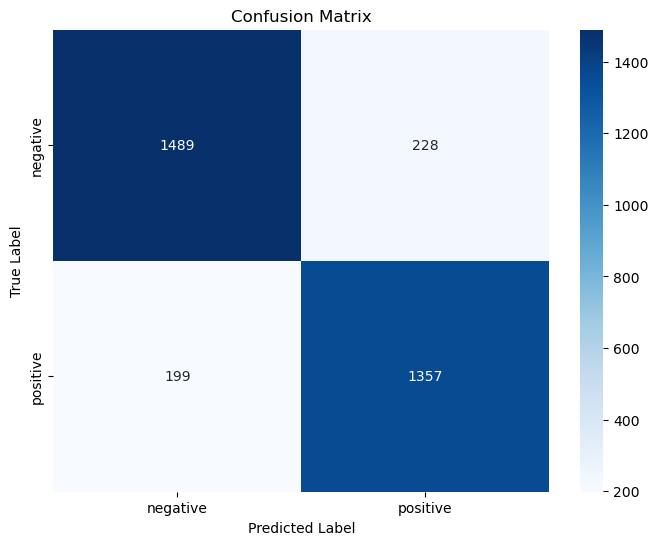

In [86]:
binary_tweets = tweets[tweets['sentiment'].isin(['positive', 'negative'])].copy() # only keep positive and negative tweets
X = binary_tweets['text'].to_list()
y = binary_tweets['sentiment']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded)

binary_sentiment_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(tokenizer=lemmatizing_tokenizer, ngram_range= (1, 3), stop_words=lemmatized_stop_words)),
    ('oversample', SMOTE(sampling_strategy='not majority')),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(128,64),
        learning_rate_init = 0.0001, # slowing down works slighly better
        max_iter=150,
        early_stopping=True,
        verbose=True,
        n_iter_no_change=5,
        validation_fraction=0.2
    ))
])

binary_sentiment_pipeline.fit(X_train, y_train_encoded)

y_pred_encoded = binary_sentiment_pipeline.predict(X_test)

y_pred_original = le.inverse_transform(y_pred_encoded)
y_test_original = le.inverse_transform(y_test_encoded)

print("\nClassification Report:")
target_names = le.classes_
print(classification_report(y_test_original, y_pred_original))

conf_matrix = confusion_matrix(y_test_original, y_pred_original, labels=['positive', 'negative'])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

Looks like dropping the neutral class significantly improves model performance (f1-score increases almost 20% from .69 to .87). This was somewhat to be expect as classifying whether something is positive or neutral or negative or neutral is probably a lot more nuanced than saying something is positive or negative. This was visible in the confusion matrix for the positive, negative, neutral model as well as most prediction errors where made in the neutral class, rather than in the positve or negative one.

## Task 4: PMI-based word similarity

In [42]:
# pre-processing steps and lemmatisation
tweets = pd.read_csv('TweetSentiment.csv')['text'].dropna()
tweets = [lemmatizing_tokenizer(normalise_tweets(t)) for t in tweets]

# Count word frequencies: 
# get count of all words
all_words = list(itertools.chain.from_iterable(tweets))
word_frequencies = Counter(all_words)

# get probabilities of all words occuring
total_number_words = sum(word_frequencies.values())
p_word = {word: count / total_number_words for word, count in word_frequencies.items()}

# Count word co-occurence frequencies
cooccurrence_counts = Counter()

for tweet in tweets:
    for w1, w2 in itertools.pairwise(tweet): # efficient function to find overlapping pairs
        sorted_pair = tuple(sorted((w1, w2)))
        cooccurrence_counts[sorted_pair] += 1

total_pairs = sum(cooccurrence_counts.values())
p_joint_words = {pair: count / total_pairs for pair, count in cooccurrence_counts.items()}

num_random_words = 10
random_words = random.sample(list(p_word.keys()), num_random_words)
print("Random words: ",random_words)

# PMI[(word_i, word_j)] = math.log2(p_joint_words[(word_i, word_j)]/(p_word[word_i]*p_word[word_j]))
Highest_PMI_words = {}
for word in random_words:
    Highest_PMI_words[word] = ('', -np.inf)
    for (x,y), value in p_joint_words.items():
        if x == word:
            pmi = math.log2(p_joint_words[(x, y)]/(p_word[x]*p_word[y]))
            if pmi > Highest_PMI_words[word][1]:
                Highest_PMI_words[word] = (y, pmi)
        elif y == word:
            pmi = math.log2(p_joint_words[(x, y)]/(p_word[x]*p_word[y]))
            if pmi > Highest_PMI_words[word][1]:
                Highest_PMI_words[word] = (x, pmi)
    
Highest_PMI_words

Random words:  ['drumstick', 'slapton', 'sucker', 'foa', 'holdin', 'happiletter', 'morningmidday', 'hudgens', 'depresses', 'judy']


{'drumstick': ('fry', 14.542958221605982),
 'slapton': ('stupid', 11.487675786104793),
 'sucker': ('for', 6.29147581098577),
 'foa': ('real', 11.788070719442514),
 'holdin': ('kale', 17.542958221605982),
 'happiletter': ('my', 6.109112013163158),
 'morningmidday': ('nation', 16.957995720884828),
 'hudgens': ('vanessa', 15.957995720884826),
 'depresses': ('me', 7.074334178687964),
 'judy': ('same', 9.230075266321627)}

## Bonus Task: Pre-trained embedding and RNN model

## Multi-class

In [19]:
tweets = pd.read_csv('TweetSentiment.csv').dropna() #reading in fresh because bert requires different pre-processing, again remove any nan tweets

# a lot less pre-processing is required for a transformer based embedding, as the models are trained to correctly 
# interpret things like upper case, punctuation and numbers.
def normalise_tweets_bert(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # remove urls
    text = re.sub(r'\@\w+', '', text) # remove mentions
    text = re.sub(r'\s+', ' ', text).strip() # normalise whitespace
    return text

tweet_list = [normalise_tweets_bert(t) for t in tweets['text']]

In [20]:
model_name = "cardiffnlp/twitter-roberta-base-emotion"  # roberta is optimised to produce embeddings for twitter text - likely lead to better results than standard bert
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)
model.eval()

embedding_dim = 768   # bert-base hidden layer size
batch_size = 1024 # using larger batch size to speed up embeddings
max_len = 128 # most important information in a tweet will lie in the first 128 characters while balancing computational cost
final_shape = (len(tweet_list), max_len, embedding_dim)

# my memory was to small to save all embeddings - solution is to save to disk
output_path = "/Users/lawrence/Desktop/nlp_embeddings/bert_token_embeddings.mmap"
final_hidden_states = np.memmap(output_path, dtype='float32', mode='w+', shape=final_shape)

for i in tqdm(range(0, len(tweet_list), batch_size)):
    
    # tokenising batch
    batch_tweets = tweet_list[i:i+batch_size]
    inputs = tokenizer(batch_tweets, return_tensors="pt", padding='max_length', truncation=True, max_length=max_len)

    with torch.no_grad(): outputs = model(**inputs)
    
    last_hidden_state = outputs.last_hidden_state
    final_hidden_states[i : i + batch_size] = last_hidden_state.numpy()

final_hidden_states.flush()

Some weights of RobertaModel were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-emotion and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|███████████████████████████████████████████| 27/27 [22:35<00:00, 50.21s/it]


In [21]:
embeddings_path = "/Users/lawrence/Desktop/nlp_embeddings/bert_token_embeddings.mmap" 
model_save_path = "best_sentiment_rnn.pth" 

# model & training parameters - relatively standard, don't have computational resources to perform gridsearch here unfortunately
num_classes = 3       # negative, neutral, positive
hidden_dim = 256      # size of the RNN hidden layer
hidden_layers = 2
num_epochs = 5
batch_size = 64
learning_rate = 0.001
shape = (len(tweet_list), max_len, embedding_dim)
patience = 3

le = LabelEncoder()
labels_numerical = le.fit_transform(tweets['sentiment'])

class EmbeddingDataset(Dataset):
    def __init__(self, embeddings_path, labels, shape):
        self.embeddings = np.memmap(embeddings_path, dtype='float32', mode='r', shape=shape)
        self.labels = labels 

    def __len__(self):
        # return total number of samples
        return len(self.labels)

    def __getitem__(self, idx):
        # retrieve single sample
        item_embedding = torch.tensor(self.embeddings[idx], dtype=torch.float32)
        # get the corresponding label
        item_label = torch.tensor(self.labels[idx], dtype=torch.long)
       
        return item_embedding, item_label
        

full_dataset = EmbeddingDataset(embeddings_path, labels_numerical, shape)

dataset_indices = list(range(len(full_dataset)))
train_indices, val_indices = train_test_split(dataset_indices, test_size=0.2)

train_subset = Subset(full_dataset, train_indices)
val_subset = Subset(full_dataset, val_indices)

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)


class DownstreamRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(DownstreamRNN, self).__init__()
        # LSTM layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=hidden_layers, batch_first=True, bidirectional=True, dropout=0.2)
        
        # linear layer to map LSTM output to class predictions
        # input features hidden_dim * 2 since LSTM bidirectional
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, embedding_dim)
        
        # LSTM returns output of each time step, plus the final hidden and cell states, but only need the final hidden state to make a classification
        _ , (hidden, _) = self.lstm(x)
        # hidden shape: (num_layers * num_directions, batch_size, hidden_dim)

        # concatenate final forward, backward hidden states hidden[-2,:,:], 
        # hidden[-2,:,:] is the last forward hidden state
        # hidden[-1,:,:] is the last backward hidden state
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        # hidden shape after cat: (batch_size, hidden_dim * 2)
        
        # pass the concatenated hidden state to the final linear layer
        out = self.fc(hidden)
        # out shape: (batch_size, num_classes)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# instantiate the model, loss function, and optimiser
model = DownstreamRNN(embedding_dim, hidden_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# early stopping
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(num_epochs):
    model.train() # set to training mode
    total_train_loss = 0
    
    # training loop
    for embeddings, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]"):
        embeddings = embeddings.to(device)
        labels = labels.to(device)

        # forward pass
        outputs = model(embeddings)
        loss = criterion(outputs, labels)

        # backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()

    # validation loop
    model.eval()  # set to evaluation mode
    total_val_loss = 0
    correct_predictions = 0
    total_samples = 0
    
    with torch.no_grad(): # no need to calculate gradients during validation
        for embeddings, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]"):
            embeddings = embeddings.to(device)
            labels = labels.to(device)
            
            outputs = model(embeddings)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()
            
    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = (correct_predictions / total_samples) * 100
    
    print(f"Epoch {epoch+1}/{num_epochs}"
          f"Train Loss: {np.round(avg_train_loss, 4)}, "
          f"Val Loss: {np.round(avg_val_loss, 4)}, "
          f"Val Accuracy: {np.round(val_accuracy, 4)}%")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), model_save_path)
    else:
        epochs_no_improve += 1
 
if os.path.exists(model_save_path):
    # instantiate new model and load saved state dictionary
    final_model = DownstreamRNN(embedding_dim, hidden_dim, num_classes)
    final_model.load_state_dict(torch.load(model_save_path))
    final_model.to(device)
    final_model.eval() # set evaluation mode
else:
    final_model = model

Epoch 1/5 [Validation]: 100%|███████████████████| 86/86 [00:25<00:00,  3.37it/s]


Epoch 1/5Train Loss: 0.6477, Val Loss: 0.6193, Val Accuracy: 72.5255%


Epoch 2/5 [Validation]: 100%|███████████████████| 86/86 [00:35<00:00,  2.41it/s]


Epoch 2/5Train Loss: 0.6021, Val Loss: 0.6066, Val Accuracy: 72.6346%


Epoch 3/5 [Validation]: 100%|███████████████████| 86/86 [00:26<00:00,  3.20it/s]


Epoch 3/5Train Loss: 0.5834, Val Loss: 0.5971, Val Accuracy: 73.7627%


Epoch 4/5 [Validation]: 100%|███████████████████| 86/86 [00:26<00:00,  3.19it/s]


Epoch 4/5Train Loss: 0.5709, Val Loss: 0.5902, Val Accuracy: 74.4905%


Epoch 5/5 [Validation]: 100%|███████████████████| 86/86 [00:25<00:00,  3.31it/s]

Epoch 5/5Train Loss: 0.5586, Val Loss: 0.5863, Val Accuracy: 74.6543%


### Evaluation

Evaluating: 100%|███████████████████████████████| 86/86 [00:26<00:00,  3.27it/s]


Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.76      0.76      1541
     neutral       0.70      0.75      0.72      2263
    positive       0.82      0.73      0.77      1692

    accuracy                           0.75      5496
   macro avg       0.76      0.75      0.75      5496
weighted avg       0.75      0.75      0.75      5496



Text(0.5, 1.0, 'Confusion Matrix')

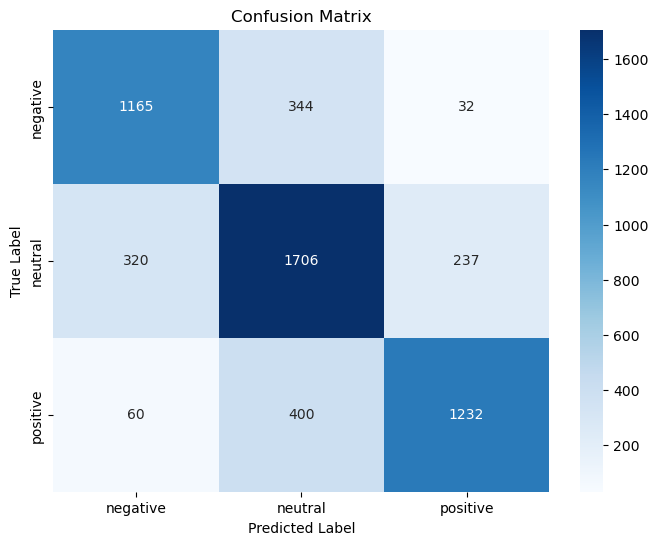

In [22]:
final_model.eval()  # Set the model to evaluation mode
predictions, true_labels = [], []

# disable gradient computation for evaluation
with torch.no_grad():
    # iterate over the validation data
    for embeddings, labels in tqdm(val_loader, desc="Evaluating"):
        embeddings = embeddings.to(device)  # pre-computed embeddings
        labels = labels.to(device)         # true labels

        # forward pass
        logits = final_model(embeddings)
        
        # get predicted class (the index of the max logit)
        preds = torch.argmax(logits, dim=1)

        # collect predictions and true labels
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())


print("\nClassification Report:")
target_names = le.classes_
print(classification_report(true_labels, predictions, target_names=target_names))

conf_matrix = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

## Binary

In [23]:
# Modify embeddings for binary data
# dropping neutral tweets once more
binary_tweets = tweets[tweets['sentiment'].isin(['positive', 'negative'])].copy()
tweet_list = list(binary_tweets['text'])
binary_index = binary_tweets.index.to_list()

model_name = "cardiffnlp/twitter-roberta-base-emotion"  # roberta is optimised to produce embeddings for twitter text - likely lead to better results than standard bert
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)
model.eval()

embedding_dim = 768   # bert-base hidden layer size
batch_size = 1024 # using larger batch size to speed up embeddings
max_len = 128 # most important information in a tweet will lie in the first 128 characters
final_shape = (len(tweet_list), max_len, embedding_dim)

le = LabelEncoder()
y = le.fit_transform(binary_tweets['sentiment'])

# my memory was to small to save all embeddings - solution is to save to disk
output_path = "/Users/lawrence/Desktop/nlp_embeddings/bert_token_embeddings_binary.mmap"
final_hidden_states = np.memmap(output_path, dtype='float32', mode='w+', shape=final_shape)

for i in tqdm(range(0, len(tweet_list), batch_size)):
    
    # tokenise batch
    batch_tweets = tweet_list[i:i+batch_size]
    inputs = tokenizer(batch_tweets, return_tensors="pt", padding='max_length', truncation=True, max_length=max_len)

    with torch.no_grad(): outputs = model(**inputs)
    
    last_hidden_state = outputs.last_hidden_state
    final_hidden_states[i : i + batch_size] = last_hidden_state.numpy()

final_hidden_states.flush()

Some weights of RobertaModel were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-emotion and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|███████████████████████████████████████████| 16/16 [14:11<00:00, 53.19s/it]


In [24]:
binary_embeddings_path = "/Users/lawrence/Desktop/nlp_embeddings/bert_token_embeddings_binary.mmap" 
binary_model_save_path = "best_sentiment_rnn_binary.pth" 

# model parameters
num_classes = 2       
hidden_dim = 256      
num_epochs = 2
batch_size = 64
learning_rate = 0.001
shape = (len(y), max_len, embedding_dim)
patience = 3

dataset_binary = EmbeddingDataset(binary_embeddings_path, y, shape)

dataset_indices = list(range(len(dataset_binary)))
train_indices, val_indices = train_test_split(dataset_indices, test_size=0.2, stratify=y)

train_subset = Subset(dataset_binary, train_indices)
val_subset = Subset(dataset_binary, val_indices)

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DownstreamRNN(embedding_dim, hidden_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(num_epochs):
    model.train()  # set to training mode
    total_train_loss = 0
    
    # training loop
    for embeddings, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]"):
        embeddings = embeddings.to(device)
        labels = labels.to(device)

        # forward pass
        outputs = model(embeddings)
        loss = criterion(outputs, labels)

        # backward pass and optimisation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()

    # val loop
    model.eval()  # set to evaluation mode
    total_val_loss = 0
    correct_predictions = 0
    total_samples = 0
    
    with torch.no_grad(): # no need to calculate gradients during validation
        for embeddings, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]"):
            embeddings = embeddings.to(device)
            labels = labels.to(device)
            
            outputs = model(embeddings)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()
            
    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = (correct_predictions / total_samples) * 100
    
    print(f"Epoch {epoch+1}/{num_epochs}"
          f"Train Loss: {np.round(avg_train_loss, 4)}, "
          f"Val Loss: {np.round(avg_val_loss, 4)}, "
          f"Val Accuracy: {np.round(val_accuracy, 4)}%")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), binary_model_save_path)
    else:
        epochs_no_improve += 1
 
if os.path.exists(model_save_path):
    # instantiate new model / load saved state dictionary
    final_model = DownstreamRNN(embedding_dim, hidden_dim, num_classes)
    final_model.load_state_dict(torch.load(binary_model_save_path))
    final_model.to(device)
    final_model.eval()
else:
    final_model = model

Epoch 1/2 [Validation]: 100%|███████████████████| 52/52 [00:15<00:00,  3.36it/s]


Epoch 1/2Train Loss: 0.2207, Val Loss: 0.2151, Val Accuracy: 92.0562%


Epoch 2/2 [Validation]: 100%|███████████████████| 52/52 [00:16<00:00,  3.24it/s]

Epoch 2/2Train Loss: 0.1986, Val Loss: 0.2131, Val Accuracy: 91.8118%


### Evaluation

Evaluating: 100%|███████████████████████████████| 52/52 [00:12<00:00,  4.02it/s]


Classification Report:
              precision    recall  f1-score   support

    negative       0.93      0.89      0.91      1556
    positive       0.91      0.94      0.92      1717

    accuracy                           0.92      3273
   macro avg       0.92      0.92      0.92      3273
weighted avg       0.92      0.92      0.92      3273



Text(0.5, 1.0, 'Confusion Matrix')

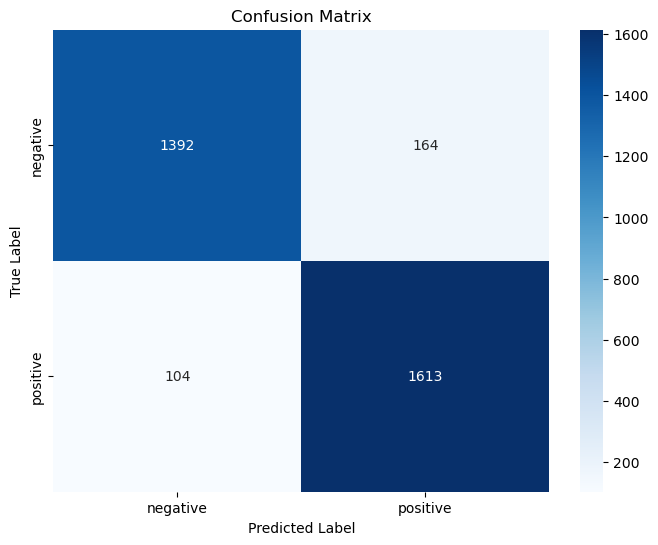

In [39]:
final_model.eval()  # set model to evaluation mode
predictions, true_labels = [], []

# disable gradient computation for evaluation
with torch.no_grad():
    # iterate over the validation data
    for embeddings, labels in tqdm(val_loader, desc="Evaluating"):
        embeddings = embeddings.to(device)  # pre-computed embeddings
        labels = labels.to(device)         # true labels
        logits = final_model(embeddings) # forward pass
        preds = torch.argmax(logits, dim=1) # get predicted class (the index of the max logit)

        # collect predictions and true labels
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print("\nClassification Report:")
target_names = le.classes_
print(classification_report(true_labels, predictions, target_names=target_names))

conf_matrix = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')